In [1]:
import sys
import os

sys.path.append(os.path.abspath(".."))

In [2]:
from src.preprocessing import load_data
from src.preprocessing import encode_features
from src.preprocessing import split_features
from src.preprocessing import scale_features

In [3]:
data = load_data("../data/raw/KDDTrain+.txt")
data = encode_features(data)
x,y = split_features(data)
x_scaled = scale_features(x)

In [4]:
from src.isolation_forest_model import train_isolation_forest

model = train_isolation_forest(x_scaled)

In [5]:
from src.isolation_forest_model import detect_anamolies

predictions = detect_anamolies(model,x_scaled)

In [6]:
import numpy as np

np.unique(predictions, return_counts = True)

(array([-1,  1]), array([50389, 75584]))

In [7]:
data['anamoly'] = predictions

In [8]:
data[data['anamoly'] == -1].head(10)

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label,anamoly
1,0,2,44,9,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.0,0.00,0.00,normal,-1
5,0,1,49,1,0,0,0,0,0,0,...,0.07,0.07,0.00,0.00,0.00,0.0,1.00,1.00,neptune,-1
10,0,1,49,1,0,0,0,0,0,0,...,0.05,0.07,0.00,0.00,0.00,0.0,1.00,1.00,neptune,-1
13,0,1,20,9,334,0,0,0,0,0,...,1.00,0.00,1.00,0.20,0.00,0.0,0.00,0.00,warezclient,-1
17,0,0,14,9,18,0,0,0,0,0,...,1.00,0.00,1.00,1.00,0.00,0.0,0.00,0.00,ipsweep,-1
23,5607,2,44,9,147,105,0,0,0,0,...,0.00,0.85,1.00,0.00,0.00,0.0,0.00,0.00,normal,-1
25,507,1,60,9,437,14421,0,0,0,0,...,0.10,0.05,0.00,0.00,0.53,0.0,0.02,0.16,normal,-1
27,0,1,24,9,227,6588,0,0,0,0,...,1.00,0.00,0.02,0.14,0.00,0.0,0.56,0.57,normal,-1
30,0,0,14,9,8,0,0,0,0,0,...,1.00,0.00,1.00,0.51,0.00,0.0,0.00,0.00,ipsweep,-1
31,0,1,18,5,0,0,0,0,0,0,...,0.23,0.04,0.01,0.00,1.00,1.0,0.00,0.00,neptune,-1


In [9]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components = 2)
x_pca = pca.fit_transform(x_scaled)

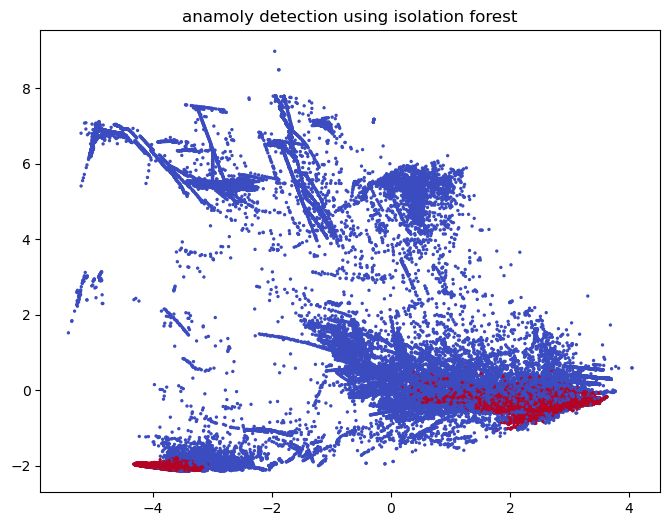

In [10]:
plt.figure(figsize = (8,6))

plt.scatter(
    x_pca[:,0],
    x_pca[:,1],
    c = predictions,
    cmap = "coolwarm",
    s=2
)

plt.title("anamoly detection using isolation forest")
plt.show()

In [11]:
import joblib

joblib.dump(model, "../results/isolation_forest_model.pkl")

['../results/isolation_forest_model.pkl']

In [12]:
data['attack'] = data['label'].apply(lambda x: 0 if x == 'normal' else 1)

In [13]:
data["predicted_attack"] = data['anamoly'].apply(lambda x: 1 if x == -1 else 0)

In [14]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(data['attack'],data['predicted_attack'])
print(cm)

[[46928 20415]
 [28656 29974]]


In [15]:
from sklearn.metrics import classification_report

print(classification_report(data['attack'],data['predicted_attack']))

              precision    recall  f1-score   support

           0       0.62      0.70      0.66     67343
           1       0.59      0.51      0.55     58630

    accuracy                           0.61    125973
   macro avg       0.61      0.60      0.60    125973
weighted avg       0.61      0.61      0.61    125973



In [16]:
data[data["predicted_attack"] == 1].shape

(50389, 45)

In [17]:
data['attack'].value_counts()

attack
0    67343
1    58630
Name: count, dtype: int64

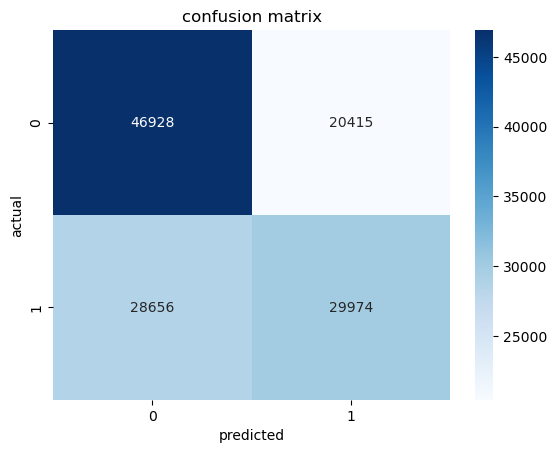

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(cm, annot = True, fmt = 'd', cmap = "Blues")
plt.title("confusion matrix")
plt.xlabel("predicted")
plt.ylabel("actual")

plt.show()

In [19]:
# Isolation Forest assumes anomalies are rare events.
# However, in the NSL-KDD dataset attacks constitute nearly half of the traffic.
# Therefore the algorithm struggles to identify many attack instances.

In [20]:
from src.dbscan_model import train_dbscan

dbscan_labels = train_dbscan(x_scaled)

In [21]:
data["dbscan_attack"] = (dbscan_labels == -1).astype(int)

confusion_matrix(data["attack"],data["dbscan_attack"])

array([[63907,  3436],
       [57415,  1215]])

In [23]:
# Isolation Forest performs significantly better than DBSCAN on the NSL-KDD dataset
# because tree-based isolation methods handle high-dimensional data more effectively
# than density-based clustering algorithms.

In [24]:
scores = model.decision_function(x_scaled)
data["anamoly_score"] = scores

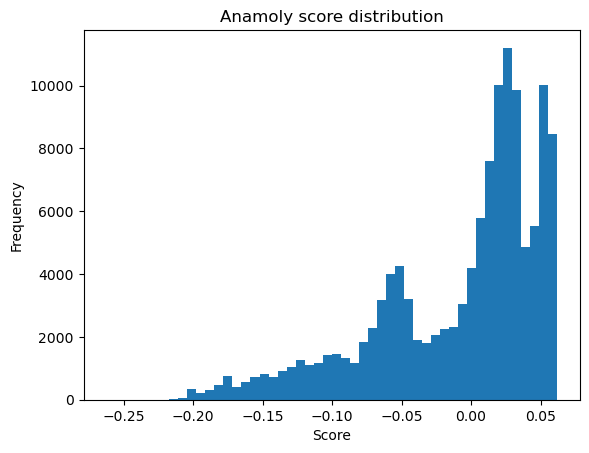

In [25]:
import matplotlib.pyplot as plt

plt.hist(data["anamoly_score"], bins = 50)
plt.title("Anamoly score distribution")
plt.xlabel("Score")
plt.ylabel("Frequency")
plt.show()

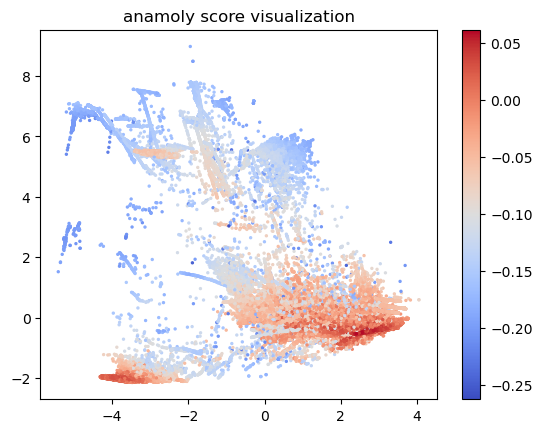

In [29]:
plt.scatter(
    x_pca[:,0],
    x_pca[:,1],
    c = data["anamoly_score"],
    cmap = "coolwarm",
    s=2
)
plt.colorbar()
plt.title("anamoly score visualization")
plt.show()

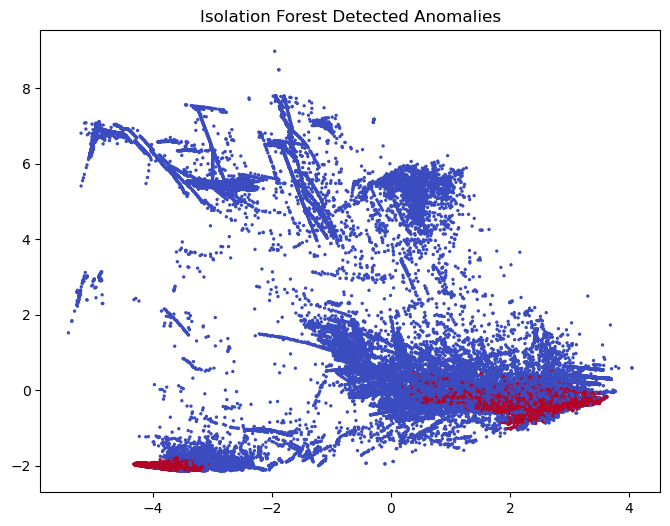

In [32]:
plt.figure(figsize=(8,6))

plt.scatter(
    x_pca[:,0],
    x_pca[:,1],
    c=data["anamoly"],
    cmap="coolwarm",
    s=2
)

plt.title("Isolation Forest Detected Anomalies")

plt.show()

In [33]:
data.sort_values("anamoly_score").head(10)

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label,anamoly,attack,predicted_attack,dbscan_attack,anamoly_score
64288,11233,1,60,9,2361,46593,0,0,0,8,...,0.98,0.96,0.00,0.00,normal,-1,0,1,1,-0.262597
53128,24,1,53,2,358678,252,0,0,0,0,...,0.00,0.00,0.33,1.00,normal,-1,0,1,1,-0.260431
25095,12743,1,60,9,4113,51633,0,0,0,0,...,0.00,0.00,0.96,0.67,ipsweep,-1,1,1,1,-0.259300
80967,11045,1,60,4,1836,129701,0,0,0,0,...,0.51,0.62,0.00,0.02,normal,-1,0,1,1,-0.258103
87054,0,1,60,6,224,2776333,0,0,0,0,...,0.14,0.20,0.00,0.00,normal,-1,0,1,1,-0.254838
47227,0,1,60,6,303,31907,0,0,0,0,...,0.01,0.14,0.75,0.29,normal,-1,0,1,1,-0.250726
7258,17903,1,60,9,5830,122343,0,0,0,77,...,0.56,0.29,0.04,0.11,normal,-1,0,1,1,-0.248660
23954,20252,1,60,2,737,112155,0,0,0,0,...,0.02,0.07,0.04,0.14,normal,-1,0,1,1,-0.247913
10006,0,1,60,6,1680,16934,0,0,0,0,...,0.00,0.33,0.74,0.33,normal,-1,0,1,1,-0.247350
111751,15211,1,60,9,454,144329,0,0,0,0,...,0.00,0.50,0.00,0.00,normal,-1,0,1,1,-0.243334
